In [35]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
import operator

In [3]:
load_dotenv()

True

In [4]:
from pydantic import BaseModel, Field

class Evaluation_schema(BaseModel):
    evaluation: Literal["approved", "need_improvement"] = Field(description="Final evaluation of the topic")
    feedback: str = Field(..., description="Give a constrcutive feedback for the evaluation")
    

In [5]:
# we willmcreate the LLM for generation, evaluation and optimization
generator_llm = ChatGroq(model = "llama-3.1-8b-instant", temperature=0.5)
evaluation_llm = ChatGroq(model = "llama-3.1-8b-instant", temperature=0.5)
optimization_llm = ChatGroq(model = "llama-3.1-8b-instant", temperature=0.5)

In [6]:
Structured_evaluation_llm = evaluation_llm.with_structured_output(Evaluation_schema)

In [ ]:
# making the state of the workflow:

class TweetState(TypedDict):
    
    topic: str
    tweet_store: str
    evaluation: Literal["approved", "need_improvement"]
    feedback: str
    iterations: int 
    max_iteration: int
    tweet_history: Annotated[list[int], operator.add]

In [8]:
def generate_tweet(state: TweetState):
    
    # prompt
    messages = [
        
        SystemMessage("You are a funny and clever Twitter/X influencer."),
        
        HumanMessage(f"""  Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

                        Rules:

                        - Do NOT use question-answer format.
                        - Max 280 characters.
                        - Use observational humor, irony, sarcasm, or cultural references.
                        - Think in meme logic, punchlines, or relatable takes.
                        - Use simple, day to day english
                        - This is version. """)
    ]
    # genertor_llm
    response = generator_llm.invoke(messages).content
    
    # returning response
    return {'tweet_store': response}

In [9]:
def evaluate_tweet(state: TweetState):
    
    # prompt
    messages = [
        
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    
    HumanMessage(content=f"""
                 
                    Evaluate the following tweet:

                    Tweet: "{state['tweet_store']}"

                    Use the criteria below to evaluate the tweet:

                    1. Originality - Is this fresh, or have you seen it a hundred times before?
                    2. Humor - Did it genuinely make you smile, laugh, or chuckle?
                    3. Punchiness - Is it short, sharp, and scroll-stopping?
                    4. Virality Potential - Would people retweet or share it?
                    5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

                    Auto-reject if:
                    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
                    - It exceeds 280 characters
                    - It reads like a traditional setup-punchline joke
                    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

                    ### Respond ONLY in structured format:
                    - evaluation: "approved" or "needs_improvement"
                    - feedback: One paragraph explaining the strengths and weaknesses
                    """)
                ] 
# evaluator_llm
    response = Structured_evaluation_llm.invoke(messages)    
    
# returning response
    return {'evaluation': response.evaluation, 'feedback': response.feedback}
    

In [24]:
def optimize_tweet(state: TweetState):
    
    # prompt
    messages = [
    SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
    HumanMessage(content=f"""
                Improve the tweet based on this feedback:
                "{state['feedback']}"

                Topic: "{state['topic']}"
                Original Tweet:
                {state['tweet_store']}

                Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
                """)
                ]
    response = optimization_llm.invoke(messages).content
    iteration = state['iterations'] + 1
    
    return {'tweet_store': response, 'iterations': iteration}

In [25]:
def route_evaluation(state: TweetState):
    
    if state['evaluation'] == "approved" or state['iterations']>=state['max_iteration']:
        return "approved"
    else:
        return "need_improvement"

In [26]:
# now lets create the grpah
graph = StateGraph(TweetState)

# since we have 3 nodes lets make them 
graph.add_node("generation_node", generate_tweet)
graph.add_node("evaluation_node", evaluate_tweet)
graph.add_node("optimization_node", optimize_tweet)

# edges lets connect the graph
graph.add_edge(START, "generation_node")
graph.add_edge("generation_node", "evaluation_node")

graph.add_conditional_edges("evaluation_node", route_evaluation, {'approved': END, 'need_improvement': 'optimization_node'})
graph.add_edge("optimization_node", "evaluation_node")


workflow = graph.compile()


In [27]:
#testing the flow
initial_state = {
    "topic": "Indian_railways",
    "iterations": 1,
    "max_iteration": 5
}

final_state = workflow.invoke(initial_state)

In [28]:
print(final_state)

{'topic': 'Indian_railways', 'tweet_store': '"Just boarded the Indian railways and I\'m already experiencing \'life\'s journey\'... by which I mean, I\'ve been stuck in a train toilet for 10 minutes and I\'m still in the station #IndianRailways #TrainLife"', 'evaluation': 'approved', 'feedback': "This tweet is a great example of original and humorous content. The use of wordplay with 'life's journey' and the clever comparison of being stuck in a train toilet to the concept of life's journey is fresh and engaging. The tweet is also short, sharp, and punchy, making it perfect for a scroll-stopping experience. The hashtags #IndianRailways and #TrainLife add to the tweet's virality potential. However, it's worth noting that the tweet could be even stronger if it had a more unexpected twist or a more unexpected ending, but overall, it's a well-crafted and entertaining tweet.", 'iterations': 1, 'max_iteration': 5}


In [34]:
from pprint import pprint

pprint(final_state)

{'evaluation': 'approved',
 'feedback': 'This tweet is a great example of original and humorous content. '
             "The use of wordplay with 'life's journey' and the clever "
             'comparison of being stuck in a train toilet to the concept of '
             "life's journey is fresh and engaging. The tweet is also short, "
             'sharp, and punchy, making it perfect for a scroll-stopping '
             'experience. The hashtags #IndianRailways and #TrainLife add to '
             "the tweet's virality potential. However, it's worth noting that "
             'the tweet could be even stronger if it had a more unexpected '
             "twist or a more unexpected ending, but overall, it's a "
             'well-crafted and entertaining tweet.',
 'iterations': 1,
 'max_iteration': 5,
 'topic': 'Indian_railways',
 'tweet_store': '"Just boarded the Indian railways and I\'m already '
                "experiencing 'life's journey'... by which I mean, I've been "
           

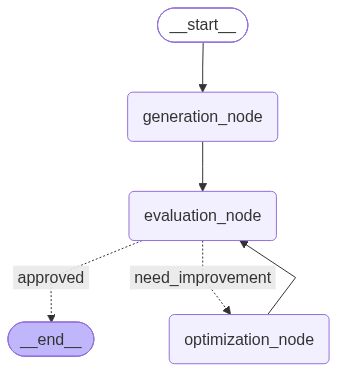

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())